In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
simulations = 10000

In [3]:

days = 252
initial_investment = 100000

# annual return and volatility assumptions
stocks = {
    "Stock A": {"return": 0.12, "volatility": 0.20},
    "Stock B": {"return": 0.08, "volatility": 0.15},
    "Stock C": {"return": 0.15, "volatility": 0.25}
}

portfolio_returns = []

for _ in range(simulations):
    total_value = 0
    for stock, params in stocks.items():
        daily_return = params["return"] / days
        daily_vol = params["volatility"] / np.sqrt(days)
        daily_changes = np.random.normal(daily_return, daily_vol, days)
        price_path = initial_investment / 3 * np.cumprod(1 + daily_changes)
        total_value += price_path[-1]
    portfolio_returns.append(total_value)

portfolio_returns = np.array(portfolio_returns)
print(f"Average Portfolio Value: ${np.mean(portfolio_returns):,.2f}")
print(f"Median Portfolio Value: ${np.median(portfolio_returns):,.2f}")
print(f"Std Deviation: ${np.std(portfolio_returns):,.2f}")

Average Portfolio Value: $112,375.52
Median Portfolio Value: $111,539.76
Std Deviation: $13,389.81


In [4]:
# calculate VaR at 95% and 99% confidence levels
var_95 = np.percentile(portfolio_returns, 5)
var_99 = np.percentile(portfolio_returns, 1)

profit_loss = portfolio_returns - initial_investment

var_95_loss = np.percentile(profit_loss, 5)
var_99_loss = np.percentile(profit_loss, 1)

print(f"Initial Investment: ${initial_investment:,.2f}")
print(f"VaR 95% Confidence: ${var_95_loss:,.2f}")
print(f"VaR 99% Confidence: ${var_99_loss:,.2f}")
print(f"Best Case: ${profit_loss.max():,.2f}")
print(f"Worst Case: ${profit_loss.min():,.2f}")

Initial Investment: $100,000.00
VaR 95% Confidence: $-7,874.24
VaR 99% Confidence: $-14,429.20
Best Case: $87,714.10
Worst Case: $-26,803.41


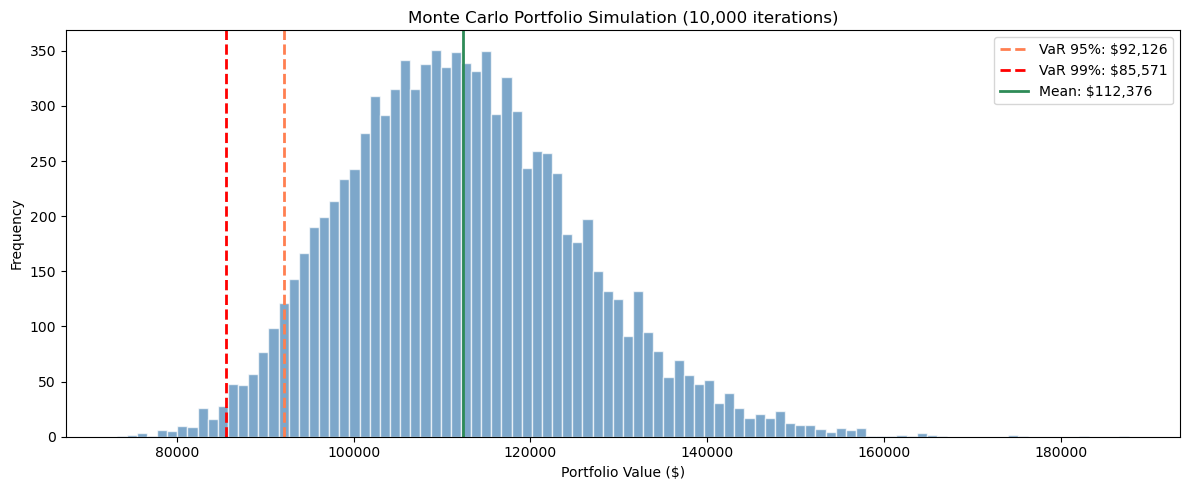

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(portfolio_returns, bins=100, color="steelblue", edgecolor="white", alpha=0.7)
ax.axvline(var_95, color="coral", linestyle="--", linewidth=2, label=f"VaR 95%: ${var_95:,.0f}")
ax.axvline(var_99, color="red", linestyle="--", linewidth=2, label=f"VaR 99%: ${var_99:,.0f}")
ax.axvline(np.mean(portfolio_returns), color="seagreen", linestyle="-", linewidth=2, label=f"Mean: ${np.mean(portfolio_returns):,.0f}")
ax.set(title=f"Monte Carlo Portfolio Simulation ({simulations:,} iterations)", xlabel="Portfolio Value ($)", ylabel="Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\monte-carlo-financial-simulation\reports\portfolio_distribution.png")
plt.show()

In [6]:
# simulate 3 year revenue under uncertainty
base_revenue = 5000000
growth_mean = 0.10
growth_std = 0.08
years = 3

revenue_scenarios = []

for _ in range(simulations):
    revenue = base_revenue
    for year in range(years):
        growth = np.random.normal(growth_mean, growth_std)
        revenue = revenue * (1 + growth)
    revenue_scenarios.append(revenue)

revenue_scenarios = np.array(revenue_scenarios)

print(f"Base Revenue: ${base_revenue:,.2f}")
print(f"Average 3Y Revenue: ${np.mean(revenue_scenarios):,.2f}")
print(f"Optimistic (95th): ${np.percentile(revenue_scenarios, 95):,.2f}")
print(f"Pessimistic (5th): ${np.percentile(revenue_scenarios, 5):,.2f}")
print(f"Probability of Growth: {(revenue_scenarios > base_revenue).mean() * 100:.1f}%")

Base Revenue: $5,000,000.00
Average 3Y Revenue: $6,655,143.05
Optimistic (95th): $8,090,966.80
Pessimistic (5th): $5,323,249.09
Probability of Growth: 98.3%


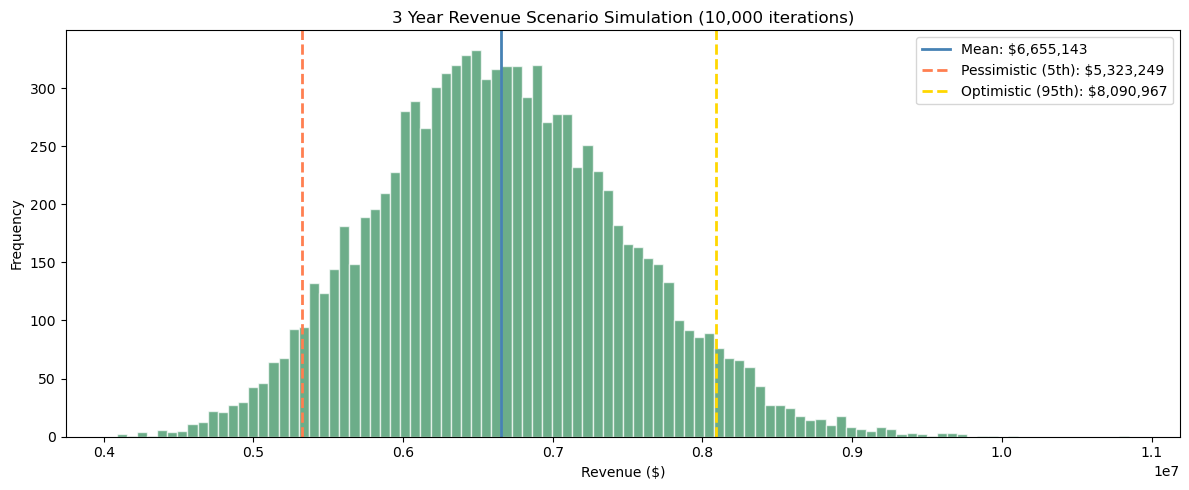

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(revenue_scenarios, bins=100, color="seagreen", edgecolor="white", alpha=0.7)
ax.axvline(np.mean(revenue_scenarios), color="steelblue", linestyle="-", linewidth=2, label=f"Mean: ${np.mean(revenue_scenarios):,.0f}")
ax.axvline(np.percentile(revenue_scenarios, 5), color="coral", linestyle="--", linewidth=2, label=f"Pessimistic (5th): ${np.percentile(revenue_scenarios, 5):,.0f}")
ax.axvline(np.percentile(revenue_scenarios, 95), color="gold", linestyle="--", linewidth=2, label=f"Optimistic (95th): ${np.percentile(revenue_scenarios, 95):,.0f}")
ax.set(title=f"3 Year Revenue Scenario Simulation ({simulations:,} iterations)", xlabel="Revenue ($)", ylabel="Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\monte-carlo-financial-simulation\reports\revenue_scenarios.png")
plt.show()

In [8]:

investment_a = {"mean_return": 0.12, "std": 0.18, "name": "Growth Investment"}
investment_b = {"mean_return": 0.07, "std": 0.08, "name": "Conservative Investment"}

returns_a = np.random.normal(investment_a["mean_return"], investment_a["std"], simulations)
returns_b = np.random.normal(investment_b["mean_return"], investment_b["std"], simulations)

print(f"{investment_a['name']}:")
print(f"  Avg Return: {np.mean(returns_a)*100:.2f}%")
print(f"  Risk (Std): {np.std(returns_a)*100:.2f}%")
print(f"  Prob Positive: {(returns_a > 0).mean()*100:.1f}%")

print(f"\n{investment_b['name']}:")
print(f"  Avg Return: {np.mean(returns_b)*100:.2f}%")
print(f"  Risk (Std): {np.std(returns_b)*100:.2f}%")
print(f"  Prob Positive: {(returns_b > 0).mean()*100:.1f}%")

Growth Investment:
  Avg Return: 12.02%
  Risk (Std): 17.97%
  Prob Positive: 75.2%

Conservative Investment:
  Avg Return: 6.98%
  Risk (Std): 7.95%
  Prob Positive: 80.7%


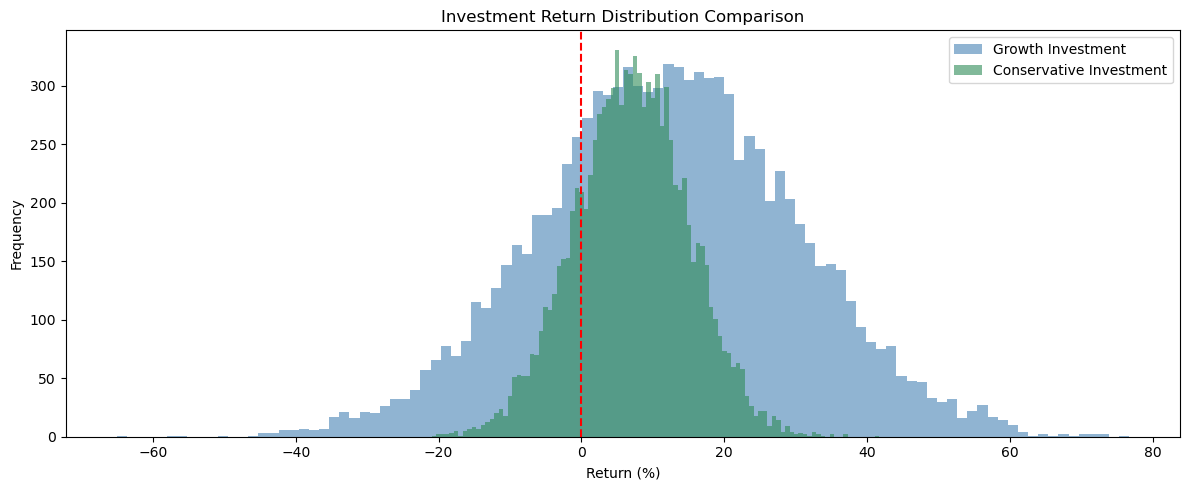

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(returns_a * 100, bins=100, color="steelblue", alpha=0.6, label=investment_a["name"])
ax.hist(returns_b * 100, bins=100, color="seagreen", alpha=0.6, label=investment_b["name"])
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set(title="Investment Return Distribution Comparison", xlabel="Return (%)", ylabel="Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\monte-carlo-financial-simulation\reports\investment_comparison.png")
plt.show()

In [10]:
results = pd.DataFrame({
    "metric": [
        "Initial Investment",
        "Avg Portfolio Value",
        "VaR 95%",
        "VaR 99%",
        "Base Revenue",
        "Avg 3Y Revenue",
        "Optimistic Revenue",
        "Pessimistic Revenue"
    ],
    "value": [
        initial_investment,
        np.mean(portfolio_returns),
        var_95_loss,
        var_99_loss,
        base_revenue,
        np.mean(revenue_scenarios),
        np.percentile(revenue_scenarios, 95),
        np.percentile(revenue_scenarios, 5)
    ]
})

results.to_csv(r"C:\Users\deepj\Documents\monte-carlo-financial-simulation\data\simulation_results.csv", index=False)
print("saved!")

saved!
